In [5]:
# librerie necessarie per il progetto
import pandas as pd  # per la gestione dei dati
import numpy as np  # per operazioni numeriche
import matplotlib.pyplot as plt  # per visualizzazioni
import seaborn as sns  # per grafici avanzati
from pandas.plotting import scatter_matrix  # per grafici scatter multipli
from sklearn.model_selection import train_test_split  # per dividere i dati
from sklearn.preprocessing import StandardScaler  # per normalizzare i dati
from sklearn.linear_model import LinearRegression  # modello di regressione lineare
from sklearn.ensemble import RandomForestRegressor  # modello Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # metriche di valutazione
import joblib  # per salvare i modelli

In [6]:
# qui carico il dataset specificando che i valori mancanti sono rappresentati da '?'.
# uso parse_dates per unire le colonne Data e Ora in un'unica colonna DateTime. Lo faccio per ottenere un oggetto datetime che mi puo permettere di:
#Ordinare i dati temporalmente
#Estrarre facilmente ora, giorno, mese, ecc.
#Fare slicing su intervalli di tempo (es. "dati solo di gennaio 2009")
#Applicare modelli basati sul tempo (es. RNN)
df = pd.read_csv('household_power_consumption.txt', sep=';', na_values='?',
                 low_memory=False, parse_dates={'DateTime': ['Date', 'Time']},
                 infer_datetime_format=True)

# mostro le prime righe per prova
df.head()

/var/folders/pm/97vkmqbn4633c6qx1lsq0xp80000gn/T/ipykernel_97056/2184601773.py:7: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('household_power_consumption.txt', sep=';', na_values='?',
/var/folders/pm/97vkmqbn4633c6qx1lsq0xp80000gn/T/ipykernel_97056/2184601773.py:7: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('household_power_consumption.txt', sep=';', na_values='?',
/var/folders/pm/97vkmqbn4633c6qx1lsq0xp80000gn/T/ipykernel_97056/2184601773.py:7: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.


,DateTime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
# dovevo capire la struttura del dataset e uso info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   DateTime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


In [8]:
# vedo le statistiche descrittive delle colonne numeriche. Le statistiche descrittive sono un insieme di valori numerici 
# che riassumono le caratteristiche principali di una colonna (o variabile) numerica in un dataset.
df.describe()

,DateTime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,2008-12-06 07:12:59.999994112,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
min,2006-12-16 17:24:00,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2007-12-12 00:18:30,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2008-12-06 07:13:00,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,2009-12-01 14:07:30,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,2010-11-26 21:02:00,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01
std,NaN,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00


In [9]:
# elimiiino le righe con valori mancanti per evitare l'insorgere dei problemi nei modelli
df = df.dropna()
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049280 entries, 0 to 2049279
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   DateTime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 125.1 MB


In [10]:
# estraggo informazioni temporali dalla colonna DateTime
df['hour'] = df['DateTime'].dt.hour  # ora del giorno
df['day_of_week'] = df['DateTime'].dt.dayofweek  # giorno della settimana (0=lunedì)
df['month'] = df['DateTime'].dt.month  # mese

# qui mostro le collonne ma solo le prima 5 solo per vedere il risultato
df[['DateTime', 'hour', 'day_of_week', 'month']].head()

,DateTime,hour,day_of_week,month
0,2006-12-16 17:24:00,17,5,12
1,2006-12-16 17:25:00,17,5,12
2,2006-12-16 17:26:00,17,5,12
3,2006-12-16 17:27:00,17,5,12
4,2006-12-16 17:28:00,17,5,12


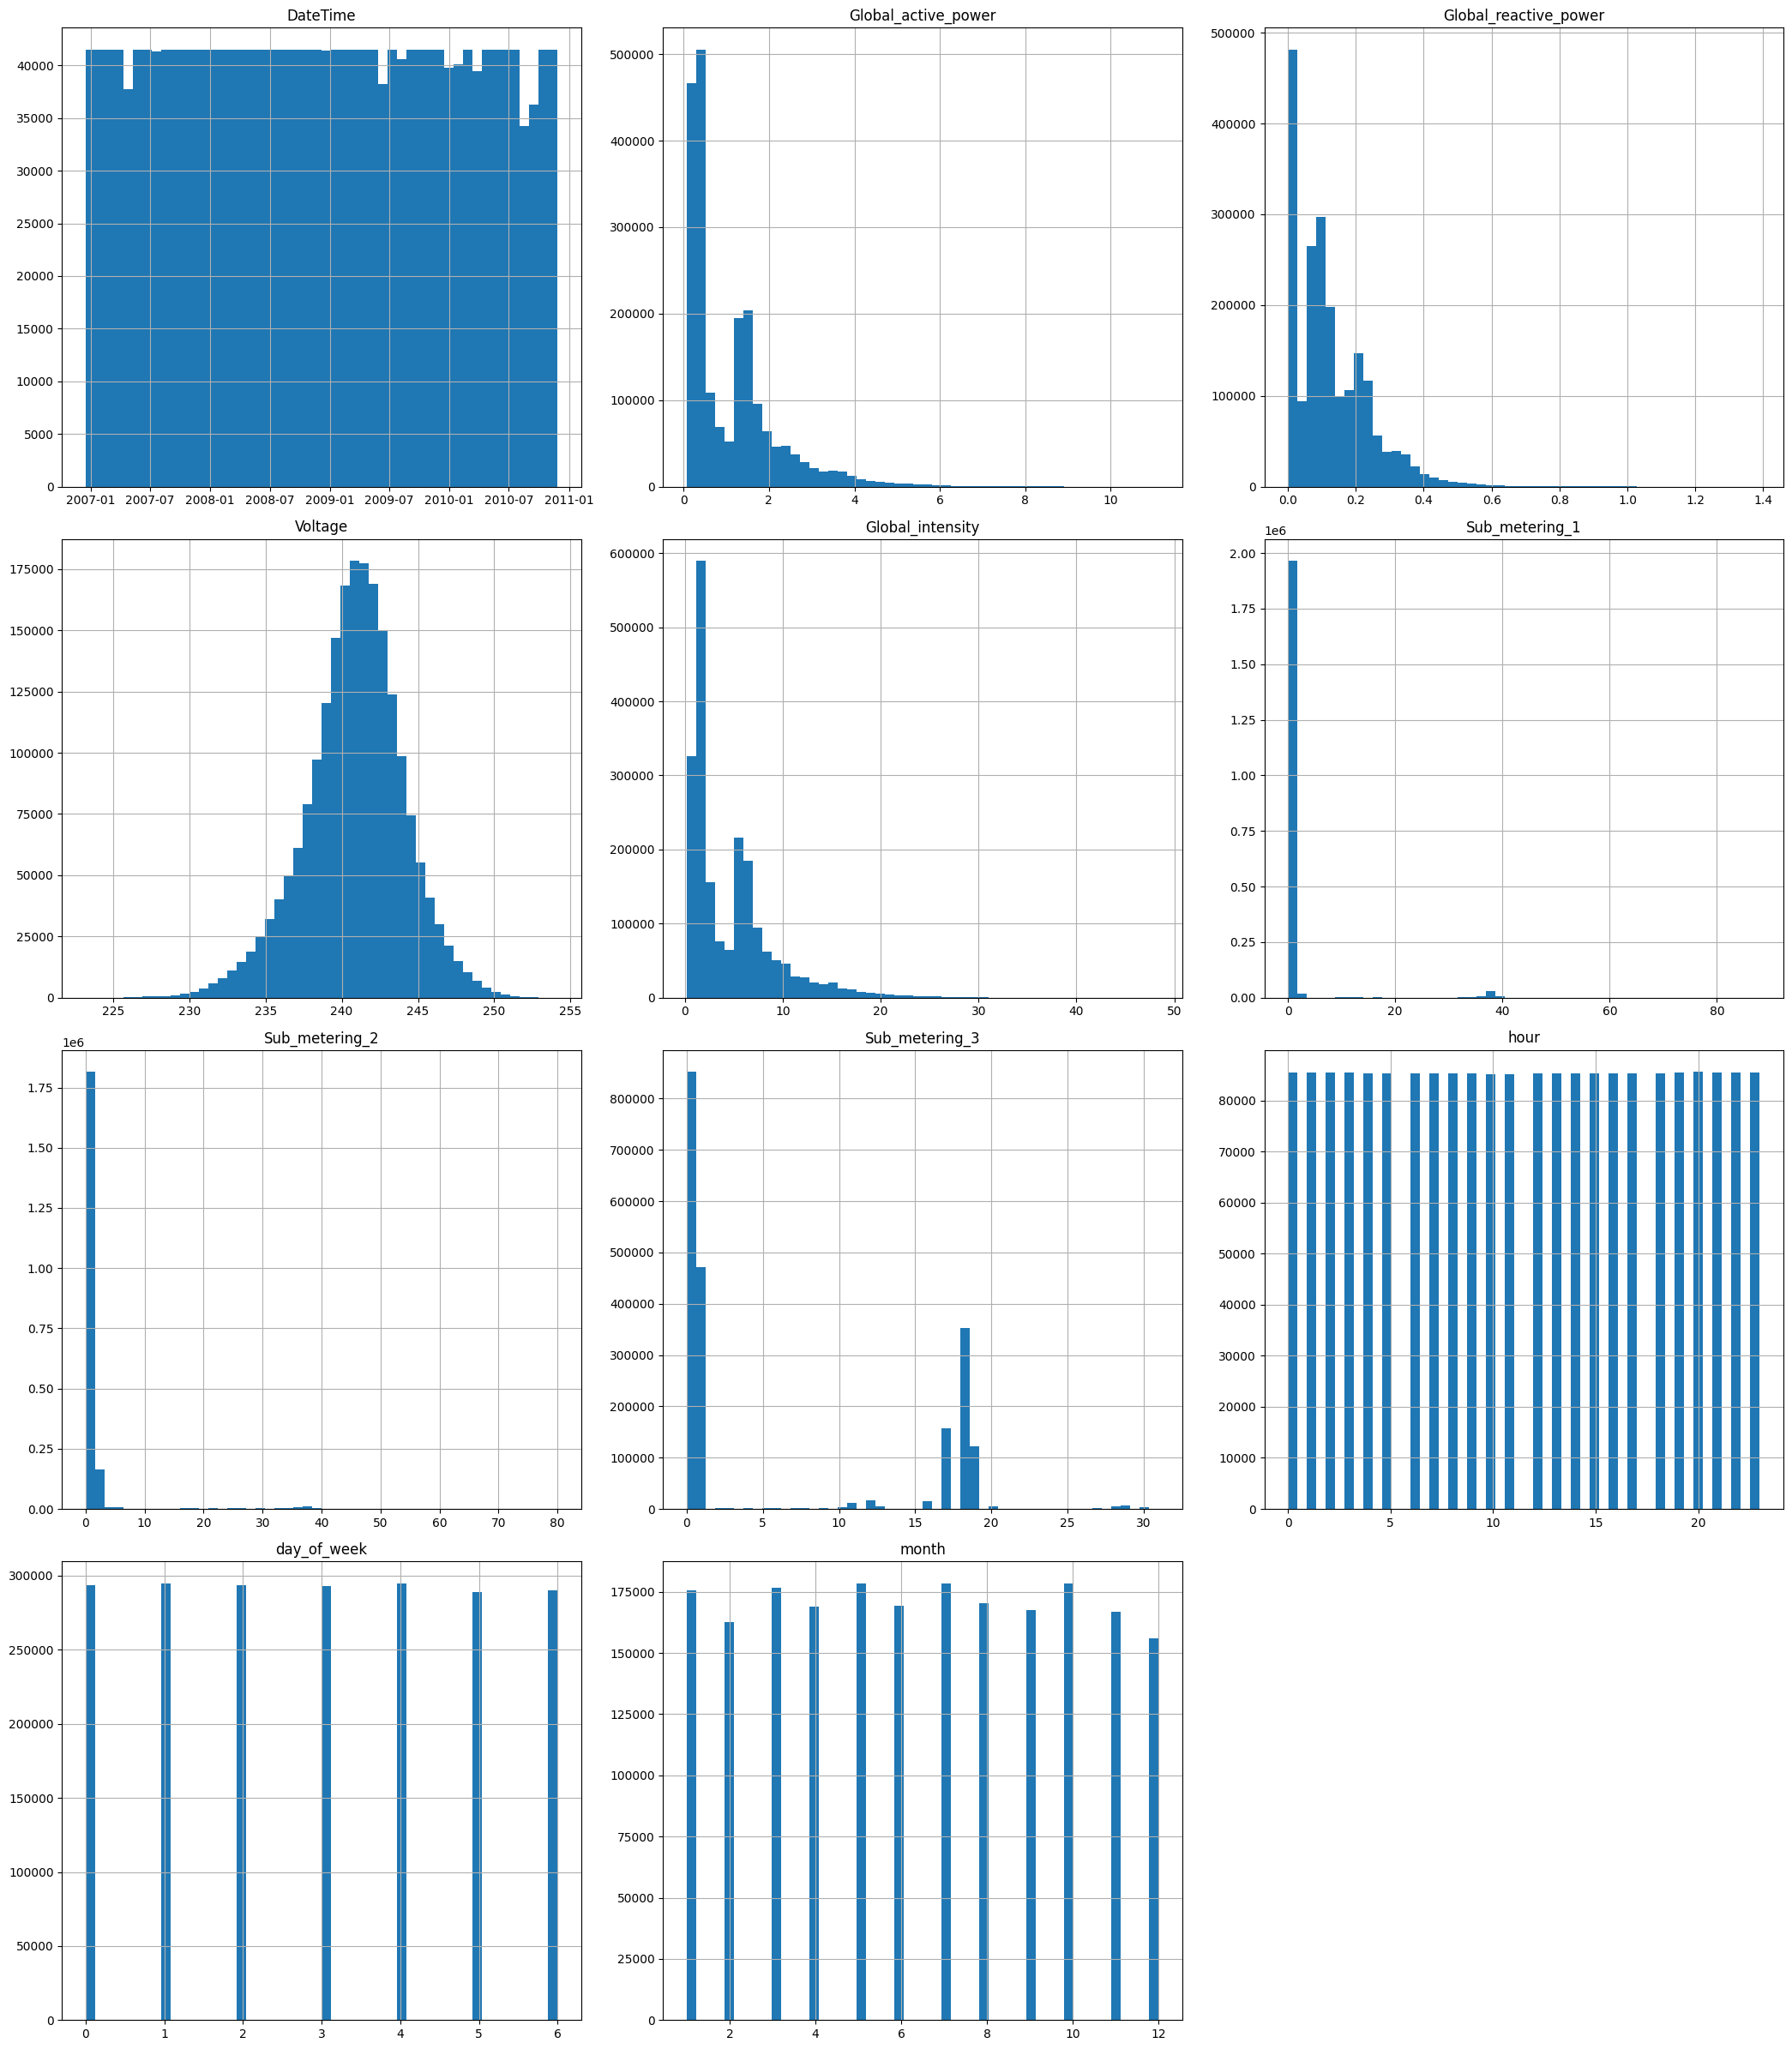

In [11]:
# faccio gli istogrammi pr visualizzare la distribuzione delle features numeriche
df.hist(figsize=(21, 24), bins=50)
plt.tight_layout()
plt.show()

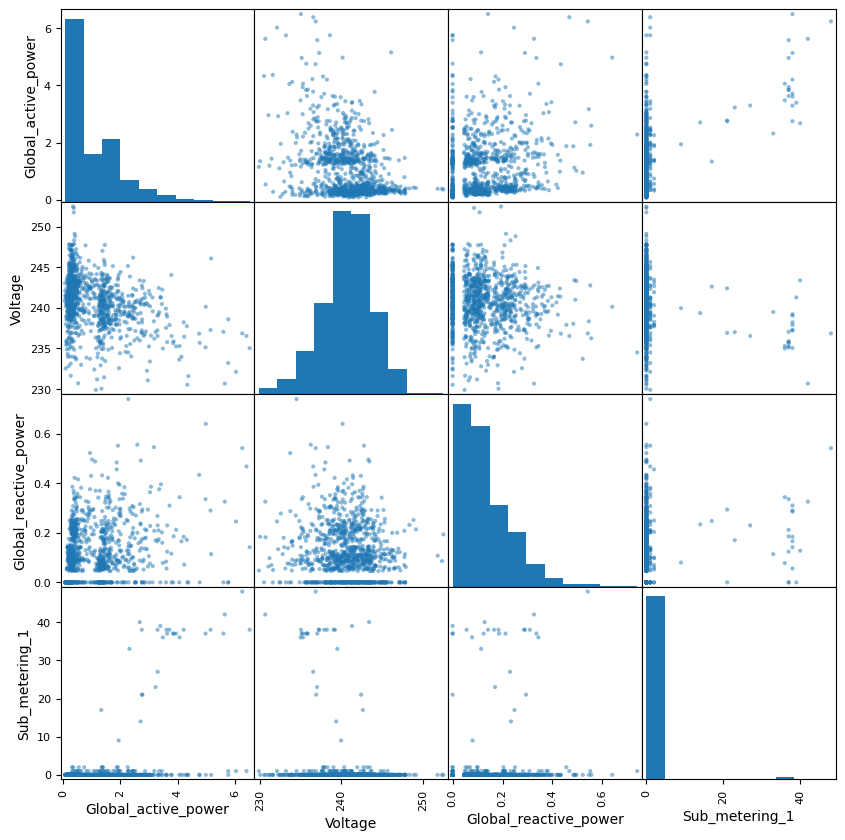

In [12]:
# Creo una matrice di grafici di dispersione su un campione di 1000 righe per guardare le relazioni
#uso sub_metering_1 per semplificare il grafico e renderlo meno pesante
campione = df[['Global_active_power', 'Voltage', 'Global_reactive_power', 'Sub_metering_1']].sample(1000)
scatter_matrix(campione, figsize=(10, 10))
plt.show()

#Si evince che:
#Global_active_power e Voltage nessuna correlazione evidente perchè punti sparsi, la tensione (Voltage) non è influenzata dal consumo attivo

#Global_active_power e Global_reactive_power leggera forma diagonale, con alcuni valori che crescono insieme cio significa che quando aumenta il consumo attivo, può aumentare anche quello reattivo

#Global_active_power e Sub_metering_1  sub_metering ha linee verticali ed assume valori discreti es:0,1,2... , correlazione nulla o molto debole perche sub_meterig_1 misura solo una parte del consumo, in momenti specifici

#Voltage e Global_reactive_power punti molto sparsi non c'è nessuna correlazione e il valore di tensione è indipendente dal consumo reattivo

#Voltage e Sub_metering_1 punti discreti distribuiti nessuna correlazione il sub-metering non è legato alla tensione sembra uguale alla relazione global active power  ma qui non c'è correlazione perchè Confronta il consumo elettrico totale con l’energia in una zona
#invece con il voltage Confronta la tensione di rete (in volt) con l’energia in una zona (es. cucina)

#Global_reactive_power e Sub_metering_1 debole correlazione infatti quando il sub-meter è attivo talvolta si accompagna a consumo reattivo ma non è una relazione stabile

#Riepilogando:
# Dallo scatter matrix vediamo le relazioni tra le variabili. 
# Global_active_power e Global_reactive_power mostrano una leggera correlazione indicando che un aumento del consumo attivo può essere accompagnato da un aumento di quello reattivo. 
# Voltage risulta scollegato dalle altre variabili, e capiamo che la tensione rimane stabile a prescindere dal tipo di consumo. 
# Sub_metering_1, invece, mostra valori discreti e relazioni poco significative, capiamo che rappresenta eventi specifici di 
# consumo (es. attivazione di un elettrodomestico), non legati direttamente alle altre grandezze elettriche.


In [13]:
# Seleziono le feature e normalizziamo i dati per i modelli
features = ['Voltage', 'Global_reactive_power', 'Sub_metering_1', 'Sub_metering_2',
            'Sub_metering_3', 'hour', 'day_of_week', 'month'] #Seleziono le varaibili che usera il modello come addestramento per fare le prevision e sono indipendenti 
X = df[features]  #le chiamo X
y = df['Global_active_power']  # variabile target che vogliamo prevedere

#Applico la normalizzazione tramite StandardScaler per garantire che tutte le feature abbiano
# lo stesso ordine di grandezza, con media 0 e deviazione standard 1. 
# Questo è importante per modelli i come la regressione lineare, che altrimenti verrebbero influenzati dalla scala delle variabili.”
s = StandardScaler()
X_s = s.fit_transform(X)

In [14]:
#Uso train_test_split per separare il dataset in una parte per l’addestramento (80%) e una per la validazione (20%). 
# In questo modo posso valutare se il modello è capace di generalizzare, cioè fare buone previsioni su dati che non ha mai visto.”
X_addestramento, X_validazione, y_addestramento, y_validazione = train_test_split(X_s, y, test_size=0.2, random_state=42)
#X_S features indipendenti normalizzate
#y features target
#20% dei dati va nel validation set il restante 80% nel training set
#42 per rendere la divisione ripetibile

In [15]:
#Con questo comando addestro un modello di regressione lineare. Il modello impara i pesi associati a ciascuna 
# feature per approssimare il consumo elettrico (Global_active_power). L’obiettivo è trovare la combinazione di 
# coefficienti che minimizza l’errore tra le previsioni e i dati reali nel training set.”
lr = LinearRegression()
lr.fit(X_addestramento, y_addestramento)

#La Random Forest (modello che unisce piu modelli semplici per crearne uno forte) costruisce molti alberi decisionali su dati casuali e aggrega i risultati. 
# Ho impostato 100 alberi con una profondità massima di 10
# il modello è in grado di prevedere il consumo elettrico in modo più flessibile rispetto alla regressione lineare, soprattutto in presenza di relazioni non lineari.”
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)#creo un modello di tipo Random Forest Regressor, che è un insieme di alberi decisionali
rf.fit(X_addestramento, y_addestramento) #run della Random Forest e la previsione finale è la media delle previsioni dei singoli alberi

RandomForestRegressor(max_depth=10, random_state=42)

In [16]:
# Funzione per valutare un modello con MAE, RMSE e R²
def analizzo_le_prestazioni(model, X_val, y_val):#1) modello già addestrato 2-3) dati di validazione (X e y) e calcola le metriche di errore
    previsioni = model.predict(X_val)#Usa il modello per fare previsioni sui dati di validazione 
    print("MAE (Errore Assoluto Medio):", mean_absolute_error(y_val, previsioni))#Media delle differenze assolute tra valori reali e previsti e, più è basso meglio è
    print("RMSE (Radice dell'Errore Quadratico Medio):", np.sqrt(mean_squared_error(y_val, previsioni))) #Penalizza di più gli errori grandi (perché eleva al quadrato) e più è basso meglio è
    print("R² (Coefficiente di Determinazione):", r2_score(y_val, previsioni))#- 1: previsione perfetta - 0: il modello è inutile - < 0: peggio della media!

In [17]:
#qui passo a valutare il modello di regressione lineare
print("\nRegressione Lineare")
analizzo_le_prestazioni(lr, X_validazione, y_validazione)


Regressione Lineare
MAE (Errore Assoluto Medio): 0.35250053800335246
RMSE (Radice dell'Errore Quadratico Medio): 0.5217126426677031
R² (Coefficiente di Determinazione): 0.7578311668691107


In [18]:
# qui passo a valutare il modello Random Forest
print("\nRandom Forest")
analizzo_le_prestazioni(rf, X_validazione, y_validazione)


Random Forest
MAE (Errore Assoluto Medio): 0.26118592057675766
RMSE (Radice dell'Errore Quadratico Medio): 0.4234407979351952
R² (Coefficiente di Determinazione): 0.8404705287749662


In [19]:
#Salvo il modello Random Forest e lo scaler
joblib.dump(rf, 'rf_model.pkl')
joblib.dump(s, 'scaler.pkl')

['scaler.pkl']

In [20]:
import joblib

# Carico il modello Random Forest e lo scaler
rf_model = joblib.load('rf_model.pkl')
scaler = joblib.load('scaler.pkl')


                 Feature  Importanza
4         Sub_metering_3    0.506140
2         Sub_metering_1    0.203037
3         Sub_metering_2    0.152965
5                   hour    0.062016
7                  month    0.031909
0                Voltage    0.022726
1  Global_reactive_power    0.019722
6            day_of_week    0.001484


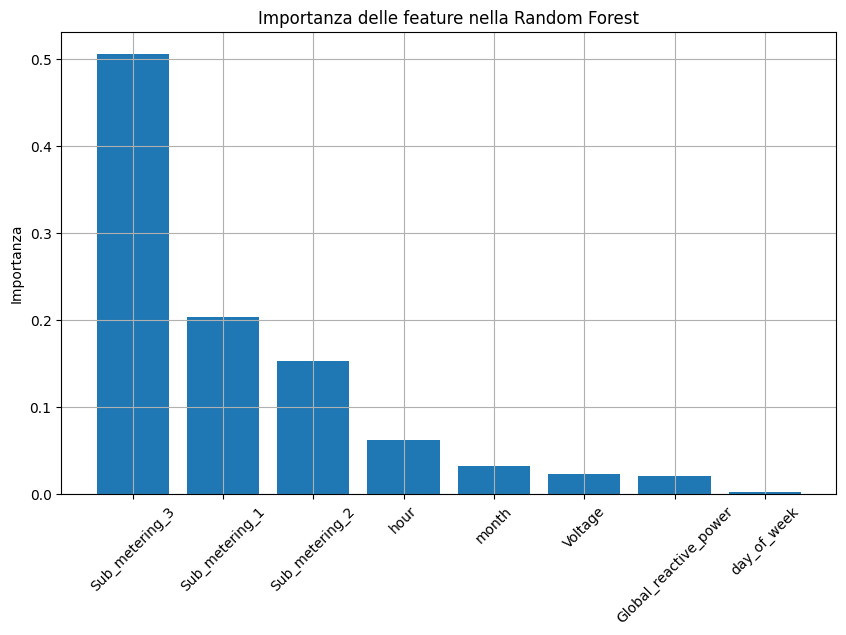

In [21]:
# Mostra le feature più importanti secondo il modello
import pandas as pd
import matplotlib.pyplot as plt

# suppongo le features
features = ['Voltage', 'Global_reactive_power', 'Sub_metering_1',
            'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'month']

# Ottieni e ordina le importanze
importanze = rf_model.feature_importances_
df_importanze = pd.DataFrame({'Feature': features, 'Importanza': importanze})
df_importanze = df_importanze.sort_values(by='Importanza', ascending=False)
print(df_importanze)

# Grafico delle importanze
plt.figure(figsize=(10, 6))
plt.bar(df_importanze['Feature'], df_importanze['Importanza'])
plt.title("Importanza delle feature nella Random Forest")
plt.ylabel("Importanza")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [22]:
# Mostra le medie e le deviazioni standard usate per normalizzare i dati
print("Media delle feature:", scaler.mean_)
print("Deviazione standard delle feature:", scaler.scale_)


Media delle feature: [2.40839858e+02 1.23714476e-01 1.12192331e+00 1.29851997e+00
 6.45844736e+00 1.15039062e+01 2.98927575e+00 6.45443278e+00]
Deviazione standard delle feature: [3.23998589 0.11272195 6.15302959 5.82202505 8.43715185 6.92518707
 1.99763207 3.4232086 ]
